# MOIRAI Forecast Comparison: Merlion vs uni2ts

This notebook compares the Moirai2 model implementation in Merlion library against the direct uni2ts implementation to verify correctness.

In [2]:
# Import required libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
from einops import rearrange

# Merlion imports
from merlion.models.forecast.moirai import Moirai, MoiraiConfig
from merlion.utils import TimeSeries

# uni2ts imports
from uni2ts.model.moirai2 import Moirai2Forecast, Moirai2Module

print("✓ All imports successful")

✓ All imports successful


## 1. Load and Prepare Data

We'll use the same dataset from the uni2ts example for consistency.

Total length: 240
Time frequency: 0 days 01:00:00
Date range: 2021-01-01 00:00:00 to 2021-01-10 23:00:00


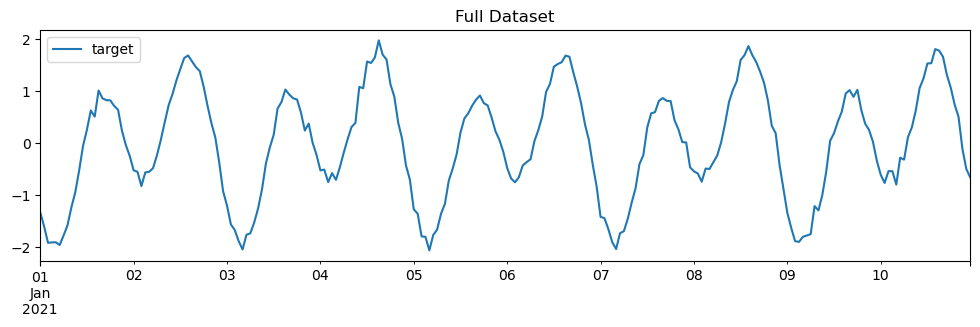

In [3]:
# Load dataframe and plot it
url = (
    "https://gist.githubusercontent.com/rsnirwan/a8b424085c9f44ef2598da74ce43e7a3"
    "/raw/b6fdef21fe1f654787fa0493846c546b7f9c4df2/ts_long.csv"
)
df = pd.read_csv(url, index_col=0, parse_dates=True)
df = df[df["item_id"] == "A"].drop(columns=["item_id"])

print(f"Total length: {df.shape[0]}")
print(f"Time frequency: {df.index.diff()[1]}")
print(f"Date range: {df.index[0]} to {df.index[-1]}")

# Plot the full dataset
df.plot(figsize=(12, 3))
plt.title("Full Dataset")
plt.show()

In [4]:
# Split data: use first 168 hours (1 week) as context, predict next 48 hours (2 days)
CONTEXT_LENGTH = 168
PREDICTION_LENGTH = 48

# Prepare context and ground truth
context_data = df["target"].to_numpy()[:CONTEXT_LENGTH]
ground_truth = df["target"].to_numpy()[CONTEXT_LENGTH:CONTEXT_LENGTH + PREDICTION_LENGTH]

context_df = df.iloc[:CONTEXT_LENGTH]
ground_truth_df = df.iloc[CONTEXT_LENGTH:CONTEXT_LENGTH + PREDICTION_LENGTH]

print(f"Context length: {len(context_data)} hours")
print(f"Prediction length: {len(ground_truth)} hours")
print(f"Context period: {context_df.index[0]} to {context_df.index[-1]}")
print(f"Prediction period: {ground_truth_df.index[0]} to {ground_truth_df.index[-1]}")

Context length: 168 hours
Prediction length: 48 hours
Context period: 2021-01-01 00:00:00 to 2021-01-07 23:00:00
Prediction period: 2021-01-08 00:00:00 to 2021-01-09 23:00:00


## 2. Forecast using uni2ts Moirai2 (Direct Implementation)

This is the reference implementation from the uni2ts library.

In [15]:
# Initialize uni2ts Moirai2 model
print("Loading uni2ts Moirai2 model...")
uni2ts_model = Moirai2Forecast(
    module=Moirai2Module.from_pretrained("Salesforce/moirai-2.0-R-small"),
    prediction_length=PREDICTION_LENGTH,
    context_length=CONTEXT_LENGTH,
    target_dim=1,
    feat_dynamic_real_dim=0,
    past_feat_dynamic_real_dim=0,
)

# Prepare input tensors
past_target = rearrange(
    torch.as_tensor(context_data, dtype=torch.float32), "t -> 1 t 1"
)

# Make prediction
print("Making uni2ts prediction...")
uni2ts_forecast = uni2ts_model.predict(past_target)

# Extract median quantile for prediction
# uni2ts_forecast shape: (batch, num_quantiles, prediction_length)
median_idx = len(uni2ts_model.module.quantile_levels) // 2
uni2ts_prediction = uni2ts_forecast[0, median_idx, :]

print(f"uni2ts prediction shape: {uni2ts_prediction.shape}")
print(f"Sample predictions (first 10): {uni2ts_prediction[:10].round(2)}")

Loading uni2ts Moirai2 model...
Making uni2ts prediction...
uni2ts prediction shape: (48,)
Sample predictions (first 10): [-0.77 -0.91 -1.02 -1.03 -0.95 -0.77 -0.53 -0.21  0.14  0.51]
Making uni2ts prediction...
uni2ts prediction shape: (48,)
Sample predictions (first 10): [-0.77 -0.91 -1.02 -1.03 -0.95 -0.77 -0.53 -0.21  0.14  0.51]


## 3. Forecast using Merlion's Moirai2 Implementation

This uses the Merlion wrapper around Moirai2.

In [9]:
# Convert context data to Merlion TimeSeries format
context_ts = TimeSeries.from_pd(context_df)

# Configure Merlion Moirai2 model
print("Configuring Merlion Moirai2 model...")
merlion_config = MoiraiConfig(
    max_forecast_steps=PREDICTION_LENGTH,
    model_variant="moirai2",
    model_size="small",
    context_length=CONTEXT_LENGTH,
    target_seq_index=0,
    device="auto",
)

# Initialize and train (load pretrained weights)
print("Loading Merlion Moirai2 model...")
merlion_model = Moirai(merlion_config)
merlion_model.train(context_ts)

# Make forecast
print("Making Merlion prediction...")
merlion_forecast, merlion_uncertainty = merlion_model.forecast(
    time_stamps=PREDICTION_LENGTH,
    time_series_prev=context_ts
)

# Convert to numpy array
merlion_prediction = merlion_forecast.to_pd().values.flatten()

print(f"Merlion prediction shape: {merlion_prediction.shape}")
print(f"Sample predictions (first 10): {merlion_prediction[:10].round(2)}")

Configuring Merlion Moirai2 model...
Loading Merlion Moirai2 model...
Making Merlion prediction...
Merlion prediction shape: (48,)
Sample predictions (first 10): [-0.77 -0.91 -1.02 -1.03 -0.95 -0.77 -0.53 -0.21  0.14  0.51]
Making Merlion prediction...
Merlion prediction shape: (48,)
Sample predictions (first 10): [-0.77 -0.91 -1.02 -1.03 -0.95 -0.77 -0.53 -0.21  0.14  0.51]


## 4. Compare Predictions

Let's compare both predictions visually and numerically.

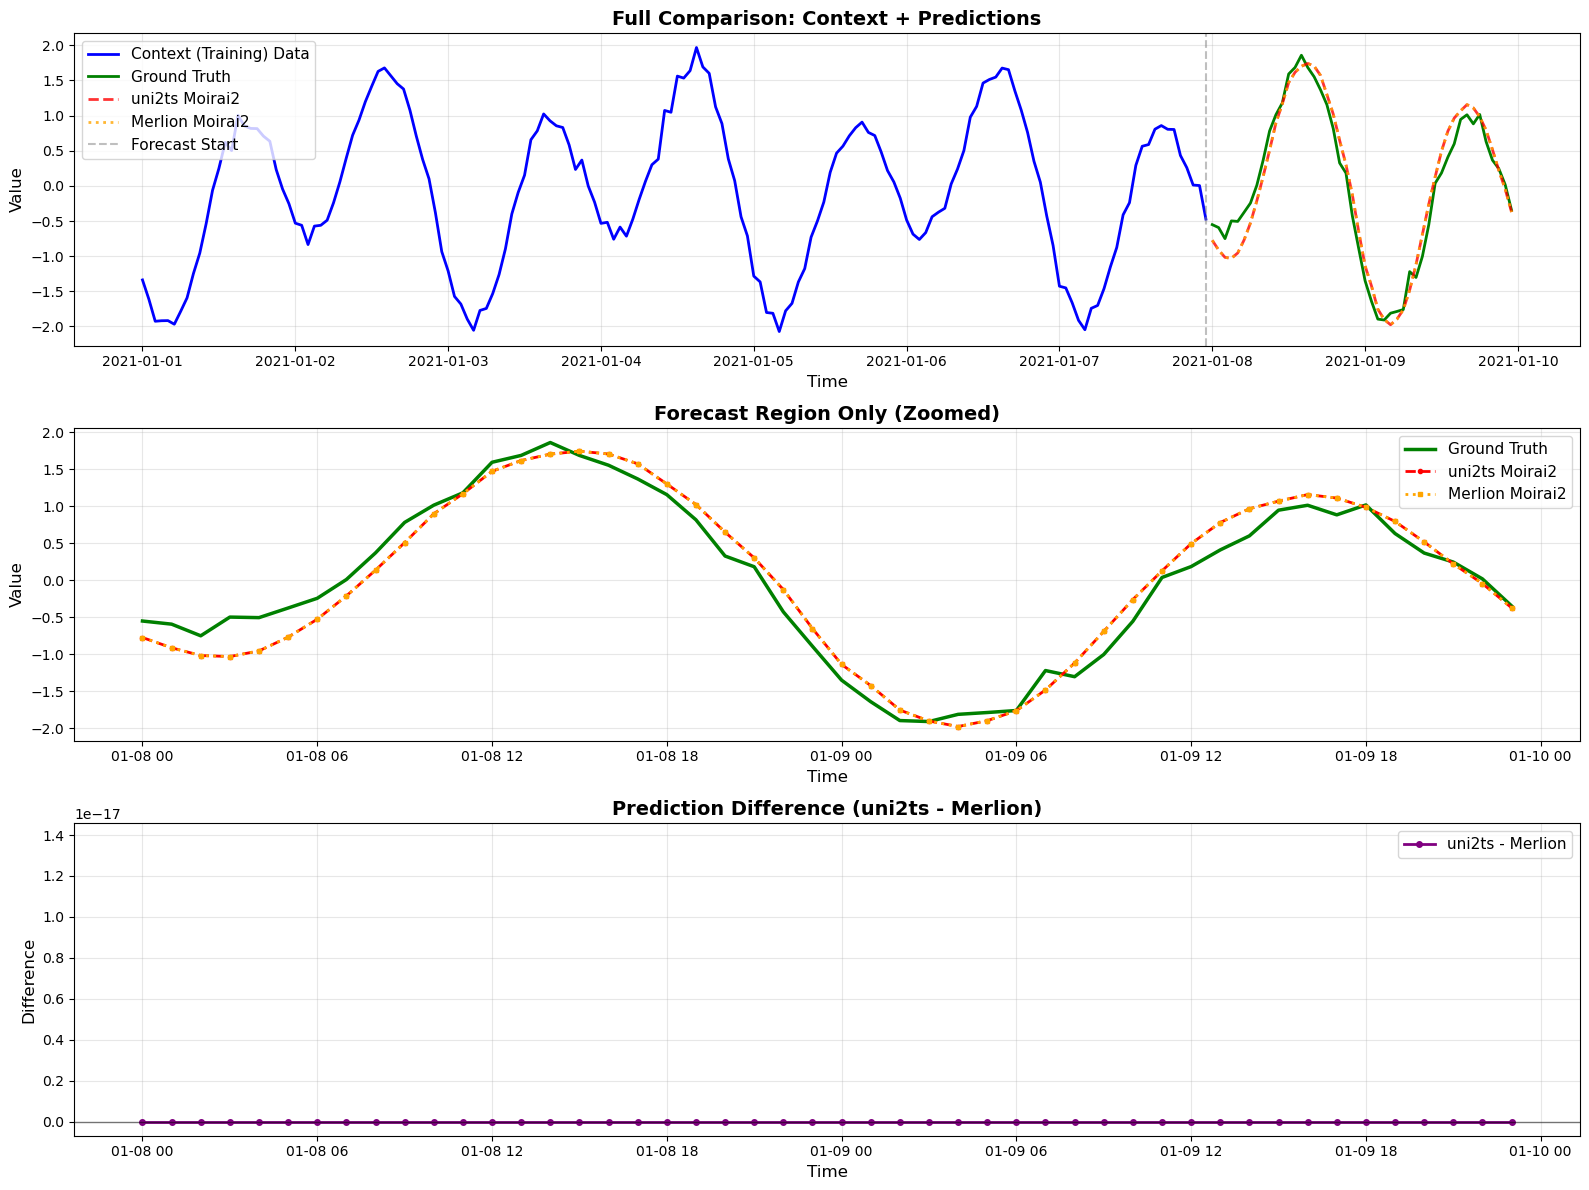

In [16]:
# Create comprehensive comparison plot
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Plot 1: Full comparison
ax1 = axes[0]
ax1.plot(context_df.index, context_data, label='Context (Training) Data', color='blue', linewidth=2)
ax1.plot(ground_truth_df.index, ground_truth, label='Ground Truth', color='green', linewidth=2)
ax1.plot(ground_truth_df.index, uni2ts_prediction, label='uni2ts Moirai2', 
         color='red', linestyle='--', linewidth=2, alpha=0.8)
ax1.plot(ground_truth_df.index, merlion_prediction, label='Merlion Moirai2', 
         color='orange', linestyle=':', linewidth=2, alpha=0.8)
ax1.axvline(x=context_df.index[-1], color='gray', linestyle='--', alpha=0.5, label='Forecast Start')
ax1.set_xlabel('Time', fontsize=12)
ax1.set_ylabel('Value', fontsize=12)
ax1.set_title('Full Comparison: Context + Predictions', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Forecast region only (zoomed in)
ax2 = axes[1]
ax2.plot(ground_truth_df.index, ground_truth, label='Ground Truth', color='green', linewidth=2.5)
ax2.plot(ground_truth_df.index, uni2ts_prediction, label='uni2ts Moirai2', 
         color='red', linestyle='--', linewidth=2, marker='o', markersize=3)
ax2.plot(ground_truth_df.index, merlion_prediction, label='Merlion Moirai2', 
         color='orange', linestyle=':', linewidth=2, marker='s', markersize=3)
ax2.set_xlabel('Time', fontsize=12)
ax2.set_ylabel('Value', fontsize=12)
ax2.set_title('Forecast Region Only (Zoomed)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Plot 3: Difference between predictions
ax3 = axes[2]
difference = uni2ts_prediction - merlion_prediction
ax3.plot(ground_truth_df.index, difference, label='uni2ts - Merlion', 
         color='purple', linewidth=2, marker='o', markersize=4)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax3.fill_between(ground_truth_df.index, difference, 0, alpha=0.3, color='purple')
ax3.set_xlabel('Time', fontsize=12)
ax3.set_ylabel('Difference', fontsize=12)
ax3.set_title('Prediction Difference (uni2ts - Merlion)', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Numerical comparison
print("=" * 80)
print("NUMERICAL COMPARISON")
print("=" * 80)

# Calculate metrics for uni2ts
uni2ts_mae = np.mean(np.abs(ground_truth - uni2ts_prediction))
uni2ts_rmse = np.sqrt(np.mean((ground_truth - uni2ts_prediction) ** 2))
uni2ts_mape = np.mean(np.abs((ground_truth - uni2ts_prediction) / ground_truth)) * 100

print("\nuni2ts Moirai2 Performance:")
print(f"  MAE:  {uni2ts_mae:.4f}")
print(f"  RMSE: {uni2ts_rmse:.4f}")
print(f"  MAPE: {uni2ts_mape:.2f}%")

# Calculate metrics for Merlion
merlion_mae = np.mean(np.abs(ground_truth - merlion_prediction))
merlion_rmse = np.sqrt(np.mean((ground_truth - merlion_prediction) ** 2))
merlion_mape = np.mean(np.abs((ground_truth - merlion_prediction) / ground_truth)) * 100

print("\nMerlion Moirai2 Performance:")
print(f"  MAE:  {merlion_mae:.4f}")
print(f"  RMSE: {merlion_rmse:.4f}")
print(f"  MAPE: {merlion_mape:.2f}%")

# Prediction similarity metrics
pred_diff_mean = np.mean(difference)
pred_diff_std = np.std(difference)
pred_diff_max = np.max(np.abs(difference))
correlation = np.corrcoef(uni2ts_prediction, merlion_prediction)[0, 1]

print("\nPrediction Similarity:")
print(f"  Mean difference:     {pred_diff_mean:.4f}")
print(f"  Std of difference:   {pred_diff_std:.4f}")
print(f"  Max abs difference:  {pred_diff_max:.4f}")
print(f"  Correlation:         {correlation:.6f}")

# Check if predictions are identical or very similar
if pred_diff_max < 1e-5:
    print("\n✓ Predictions are IDENTICAL (within numerical precision)")
elif pred_diff_max < 0.01:
    print("\n✓ Predictions are VERY SIMILAR (max difference < 0.01)")
elif correlation > 0.99:
    print("\n✓ Predictions are HIGHLY CORRELATED (r > 0.99)")
else:
    print("\n⚠ Predictions show some differences - may need investigation")

print("=" * 80)

NUMERICAL COMPARISON

uni2ts Moirai2 Performance:
  MAE:  0.1962
  RMSE: 0.2298
  MAPE: 95.00%

Merlion Moirai2 Performance:
  MAE:  0.1962
  RMSE: 0.2298
  MAPE: 95.00%

Prediction Similarity:
  Mean difference:     0.0000
  Std of difference:   0.0000
  Max abs difference:  0.0000
  Correlation:         1.000000

✓ Predictions are IDENTICAL (within numerical precision)


In [18]:
# Display sample predictions side by side
print("\nSample Predictions (first 10 timesteps):")
print("=" * 80)
comparison_df = pd.DataFrame({
    'Ground Truth': ground_truth[:10],
    'uni2ts Moirai2': uni2ts_prediction[:10],
    'Merlion Moirai2': merlion_prediction[:10],
    'Difference': difference[:10]
}, index=ground_truth_df.index[:10])
print(comparison_df.round(4))


Sample Predictions (first 10 timesteps):
                     Ground Truth  uni2ts Moirai2  Merlion Moirai2  Difference
2021-01-08 00:00:00       -0.5511         -0.7739          -0.7739         0.0
2021-01-08 01:00:00       -0.5932         -0.9124          -0.9124         0.0
2021-01-08 02:00:00       -0.7505         -1.0171          -1.0171         0.0
2021-01-08 03:00:00       -0.4978         -1.0305          -1.0305         0.0
2021-01-08 04:00:00       -0.5051         -0.9544          -0.9544         0.0
2021-01-08 05:00:00       -0.3753         -0.7690          -0.7690         0.0
2021-01-08 06:00:00       -0.2440         -0.5267          -0.5267         0.0
2021-01-08 07:00:00        0.0095         -0.2120          -0.2120         0.0
2021-01-08 08:00:00        0.3692          0.1361           0.1361         0.0
2021-01-08 09:00:00        0.7807          0.5073           0.5073         0.0


## 5. Summary

This notebook compares the Moirai2 implementation between:
- **uni2ts**: Direct implementation from the uni2ts library
- **Merlion**: Merlion's wrapper around uni2ts Moirai2

### Expected Results:
If the Merlion implementation is correct, the predictions should be:
1. **Identical or very similar** (within numerical precision)
2. **Highly correlated** (correlation coefficient close to 1.0)
3. **Similar performance metrics** (MAE, RMSE, MAPE)

### Key Points:
- Both use the same pretrained model: `Salesforce/moirai-2.0-R-small`
- Same context length: 168 hours (1 week)
- Same prediction length: 48 hours (2 days)
- Both use median quantile for point predictions